# Fase 1 — GSE126805: Transcriptional trajectories of human kidney injury progression

**Dataset:** GSE126805 — Cippà et al., JCI Insight 2018  
**Tipo:** RNA-seq (STAR/featureCounts) — matrice counts gene-level fornita dagli autori  
**Design:** 42 pazienti × 4 time points (PRE, POST, 3M, 12M) — **paired design**  
**Confronto pipeline:** baseline_post vs baseline_pre (POST vs PRE)  
**Piattaforma:** Illumina HiSeq 3000  

### Riferimenti dall'articolo
- 163 campioni totali da 42 pazienti
- DE originale: EdgeR exact test, FDR < 0.05
- Early response genes: FOS, JUN, EGR1, ATF3, FOSB, DUSP1, SOX9, KLF5
- Fibrosis markers: COL1A1, COL1A2, MMP2, MMP7, HAVCR1, VCAN
- DGF rate: 14%

In [1]:
# Setup
import pandas as pd
import numpy as np
import gzip
import os
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR = PROJECT_ROOT / "data/geo/GSE126805"
OUTPUT_DIR = PROJECT_ROOT / "output/fase1/GSE126805"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Directories create.")
print(f"Metti GSE126805_all.gene_counts.txt.gz e GSE126805_series_matrix.txt.gz in: {DATA_DIR}/")

Directories create.
Metti GSE126805_all.gene_counts.txt.gz e GSE126805_series_matrix.txt.gz in: C:\Users\rcasale\Desktop\magic_solution\data\geo\GSE126805/


## 1. Metadata dal Series Matrix

In [2]:
SERIES_MATRIX = DATA_DIR / "GSE126805_series_matrix.txt.gz"

titles = []
gsm_ids = []
patients = []
timepoints = []

with gzip.open(SERIES_MATRIX, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('!Sample_geo_accession'):
            gsm_ids = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_title'):
            titles = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_characteristics_ch1') and 'patient' in line.lower():
            patients = [x.strip('"').replace('patient: Patient #', '') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_characteristics_ch1') and 'time point' in line.lower():
            timepoints = [x.strip('"').replace('time point: ', '') for x in line.split('\t')[1:]]

meta = pd.DataFrame({
    'gsm': gsm_ids,
    'title': titles,
    'patient': patients,
    'timepoint': timepoints
})

# Standardize timepoint
tp_map = {'pre': 'PRE', 'post': 'POST', '3 months': '3M', '1 year': '12M'}
meta['timepoint_std'] = meta['timepoint'].map(tp_map)

print(f"Campioni totali: {len(meta)}")
print(f"Pazienti unici: {meta['patient'].nunique()}")
print(f"\nDistribuzione timepoints:")
print(meta['timepoint_std'].value_counts().sort_index())
meta.head(10)

Campioni totali: 163
Pazienti unici: 42

Distribuzione timepoints:
timepoint_std
12M     39
3M      41
POST    42
PRE     41
Name: count, dtype: int64


,gsm,title,patient,timepoint,timepoint_std
0,GSM3613602,sample.kidney_03_1year,03,1 year,12M
1,GSM3613603,sample.kidney_03_3months,03,3 months,3M
2,GSM3613604,sample.kidney_03_baseline_post,03,post,POST
3,GSM3613605,sample.kidney_03_baseline_pre,03,pre,PRE
4,GSM3613606,sample.kidney_02_1year,02,1 year,12M
5,GSM3613607,sample.kidney_02_3months,02,3 months,3M
6,GSM3613608,sample.kidney_02_baseline_post,02,post,POST
7,GSM3613609,sample.kidney_02_baseline_pre,02,pre,PRE
8,GSM3613610,sample.kidney_01_1year,01,1 year,12M
9,GSM3613611,sample.kidney_01_3months,01,3 months,3M


In [3]:
# VERIFICA 1: corrispondenza con articolo
assert len(meta) == 163, f"Attesi 163 campioni, trovati {len(meta)}"
assert meta['patient'].nunique() == 42, f"Attesi 42 pazienti, trovati {meta['patient'].nunique()}"
n_pre = (meta['timepoint_std'] == 'PRE').sum()
n_post = (meta['timepoint_std'] == 'POST').sum()
print(f"PRE: {n_pre}, POST: {n_post}, 3M: {(meta['timepoint_std']=='3M').sum()}, 12M: {(meta['timepoint_std']=='12M').sum()}")
print(f"Articolo riporta: ~38 PRE, ~39 POST, ~41 3M, ~39 12M (tot 163 con campioni mancanti)")
print(f"✅ Verifica metadata: 42 pazienti, 163 campioni — OK")

PRE: 41, POST: 42, 3M: 41, 12M: 39
Articolo riporta: ~38 PRE, ~39 POST, ~41 3M, ~39 12M (tot 163 con campioni mancanti)
✅ Verifica metadata: 42 pazienti, 163 campioni — OK


## 2. Caricamento matrice counts

Il file `GSE126805_all.gene_counts.txt.gz` è una matrice gene-level fornita dagli autori.  
Le colonne sono i sample titles (non GSM IDs). Le prime colonne contengono annotazione genica.

In [4]:
COUNTS_FILE = DATA_DIR / "GSE126805_all.gene_counts.txt.gz"

print("Caricamento matrice counts...")
df_raw = pd.read_csv(COUNTS_FILE, sep='\t', compression='gzip')

print(f"Dimensioni: {df_raw.shape}")
print(f"\nPrime colonne (annotazione): {list(df_raw.columns[:7])}")
print(f"Colonne campioni (prime 3): {list(df_raw.columns[7:10])}")
print(f"\nPrime 3 righe:")
df_raw.head(3)

Caricamento matrice counts...
Dimensioni: (59129, 170)

Prime colonne (annotazione): ['ensembl_gene_id', 'entrezgene', 'external_gene_name', 'gene_biotype', 'external_gene_source', 'transcript_count', 'description']
Colonne campioni (prime 3): ['sample.kidney_03_1year', 'sample.kidney_03_3months', 'sample.kidney_03_baseline_post']

Prime 3 righe:


,ensembl_gene_id,entrezgene,external_gene_name,gene_biotype,external_gene_source,transcript_count,description,sample.kidney_03_1year,sample.kidney_03_3months,sample.kidney_03_baseline_post,...,sample.kidney_31_baseline_pre,sample.kidney_30_1year,sample.kidney_30_3months,sample.kidney_30_baseline_post,sample.kidney_30_baseline_pre,sample.kidney_29_1year,sample.kidney_29_3months,sample.kidney_29_baseline_post,sample.kidney_28_1year,sample.kidney_28_3months
0,ENSG00000000003,7105.0,TSPAN6,protein_coding,HGNC Symbol,5,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858],1620,2768,2305,...,4837,1943,3346,1570,1601,3091,3565,2436,3803,2565
1,ENSG00000000005,64102.0,TNMD,protein_coding,HGNC Symbol,2,tenomodulin [Source:HGNC Symbol;Acc:HGNC:17757],25,29,23,...,58,40,61,26,4,86,433,20,260,54
2,ENSG00000000419,8813.0,DPM1,protein_coding,HGNC Symbol,6,dolichyl-phosphate mannosyltransferase subunit...,561,802,682,...,1355,839,1322,995,838,777,1063,1027,1343,1027


In [5]:
# Identifica colonne annotazione e colonne campioni
annot_cols = ['ensembl_gene_id', 'entrezgene', 'external_gene_name', 
              'gene_biotype', 'external_gene_source', 'transcript_count', 'description']
sample_cols = [c for c in df_raw.columns if c not in annot_cols]

print(f"Colonne annotazione: {len(annot_cols)}")
print(f"Colonne campioni: {len(sample_cols)}")
print(f"Corrisponde ai campioni in metadata? {len(sample_cols)} == {len(meta)}: {len(sample_cols) == len(meta)}")

# Verifica che tutti i titles nel metadata siano nelle colonne
missing = [t for t in meta['title'] if t not in sample_cols]
if missing:
    print(f"⚠️ Titles mancanti nel file counts: {missing[:5]}")
else:
    print(f"✅ Tutti i {len(meta)} sample titles trovati nel file counts")

Colonne annotazione: 7
Colonne campioni: 163
Corrisponde ai campioni in metadata? 163 == 163: True
✅ Tutti i 163 sample titles trovati nel file counts


In [6]:
# Estrai gene symbol e matrice counts
# Usa external_gene_name come gene symbol
gene_info = df_raw[['ensembl_gene_id', 'external_gene_name', 'gene_biotype']].copy()
counts_raw = df_raw[sample_cols].copy()
counts_raw.index = df_raw['external_gene_name']

# Rimuovi geni senza nome
counts_raw = counts_raw[counts_raw.index.notna() & (counts_raw.index != '')]

# Alcuni geni hanno duplicati (es. multiple Ensembl IDs → stesso gene symbol)
# Aggrega sommando (standard per counts)
n_before = len(counts_raw)
counts_raw = counts_raw.groupby(counts_raw.index).sum()
counts_raw.index.name = 'gene'

print(f"Geni prima dedup: {n_before}")
print(f"Geni dopo dedup: {len(counts_raw)}")
print(f"\nVerifica counts sono interi:")
print(f"  dtype primo campione: {counts_raw.iloc[:, 0].dtype}")
print(f"  Valori esempio: {counts_raw.iloc[:3, :3].values}")

Geni prima dedup: 59129
Geni dopo dedup: 54508

Verifica counts sono interi:
  dtype primo campione: int64
  Valori esempio: [[0 0 0]
 [0 0 0]
 [3 7 5]]


In [7]:
# VERIFICA 2: statistiche counts
total_per_sample = counts_raw.sum(axis=0)
print(f"Reads totali per campione: min={total_per_sample.min():,.0f}, median={total_per_sample.median():,.0f}, max={total_per_sample.max():,.0f}")
print(f"Geni con almeno 1 read in almeno 1 campione: {(counts_raw.sum(axis=1) > 0).sum():,}")

Reads totali per campione: min=12,222,570, median=19,374,400, max=26,624,196
Geni con almeno 1 read in almeno 1 campione: 45,452


## 3. Preprocessing

Filtro geni lowly expressed. I counts sono già interi (STAR/featureCounts).

In [8]:
# Filtro: almeno 10 reads in almeno 10 campioni (dataset grande, soglia più alta)
MIN_READS = 10
MIN_SAMPLES = 10
keep = (counts_raw >= MIN_READS).sum(axis=1) >= MIN_SAMPLES
counts_filt = counts_raw[keep]

print(f"Geni prima del filtro: {len(counts_raw):,}")
print(f"Geni dopo filtro (≥{MIN_READS} reads in ≥{MIN_SAMPLES} campioni): {len(counts_filt):,}")
print(f"Geni rimossi: {len(counts_raw) - len(counts_filt):,}")

Geni prima del filtro: 54,508
Geni dopo filtro (≥10 reads in ≥10 campioni): 18,832
Geni rimossi: 35,676


In [9]:
# Check date Excel
import re
date_pattern = re.compile(r"^\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$", re.IGNORECASE)
corrupted = [val for val in counts_filt.index.dropna().astype(str) if date_pattern.match(val)]
if not corrupted:
    print("✅ Nessuna data Excel trovata nei nomi dei geni.")
else:
    print(f"❌ Date Excel trovate: {set(corrupted)}")

✅ Nessuna data Excel trovata nei nomi dei geni.


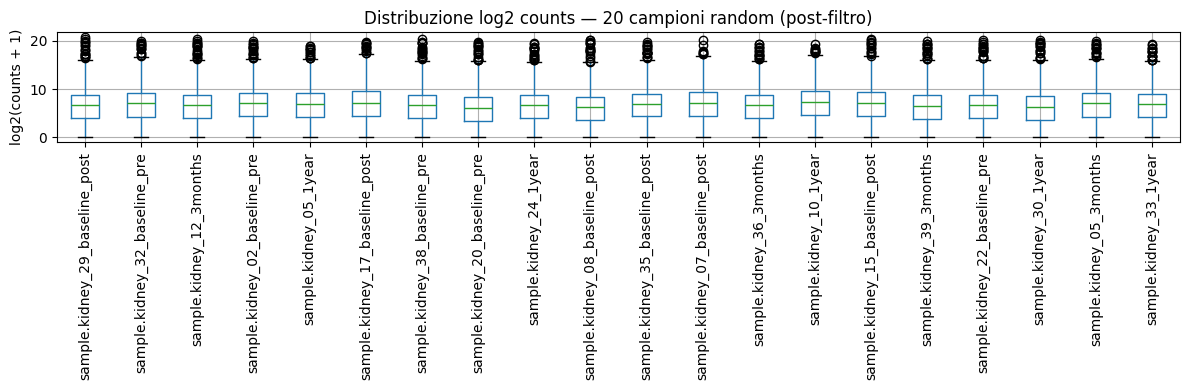

In [10]:
# Distribuzione log2(counts+1) per subset di campioni
import matplotlib.pyplot as plt

# Seleziona 20 campioni random per la visualizzazione
np.random.seed(0)
subset_cols = np.random.choice(counts_filt.columns, min(20, len(counts_filt.columns)), replace=False)

fig, ax = plt.subplots(figsize=(12, 4))
np.log2(counts_filt[subset_cols] + 1).boxplot(ax=ax, rot=90)
ax.set_ylabel('log2(counts + 1)')
ax.set_title('Distribuzione log2 counts — 20 campioni random (post-filtro)')
plt.tight_layout()
plt.show()

## 4. Definizione gruppi e design

**Confronto per la pipeline:** POST vs PRE (baseline_post vs baseline_pre)  
**Design:** paired (stesso paziente in entrambe le condizioni)  

Alcuni pazienti potrebbero non avere entrambi i timepoints. Li identifichiamo.

In [11]:
# Seleziona solo PRE e POST
meta_pp = meta[meta['timepoint_std'].isin(['PRE', 'POST'])].copy()

# Trova pazienti con entrambi i timepoints (per paired design)
pts_pre = set(meta_pp[meta_pp['timepoint_std'] == 'PRE']['patient'])
pts_post = set(meta_pp[meta_pp['timepoint_std'] == 'POST']['patient'])
pts_both = pts_pre & pts_post

print(f"Pazienti con PRE: {len(pts_pre)}")
print(f"Pazienti con POST: {len(pts_post)}")
print(f"Pazienti con entrambi: {len(pts_both)}")

# Usa solo pazienti con entrambi per paired design
meta_paired = meta_pp[meta_pp['patient'].isin(pts_both)].copy()
meta_paired = meta_paired.set_index('title')  # le colonne counts usano title, non GSM!

print(f"\nCampioni per DE (paired): {len(meta_paired)}")
print(f"  PRE: {(meta_paired['timepoint_std'] == 'PRE').sum()}")
print(f"  POST: {(meta_paired['timepoint_std'] == 'POST').sum()}")

Pazienti con PRE: 41
Pazienti con POST: 42
Pazienti con entrambi: 41

Campioni per DE (paired): 82
  PRE: 41
  POST: 41


In [12]:
# Prepara matrice counts per pyDESeq2 (samples × genes)
sample_titles = list(meta_paired.index)
counts_de = counts_filt[sample_titles].T

# Clinical data per pyDESeq2
clinical = meta_paired[['timepoint_std', 'patient']].copy()
clinical.columns = ['condition', 'patient']

# Verifica allineamento
assert list(counts_de.index) == list(clinical.index), "Mismatch indici!"
print(f"Matrice DE: {counts_de.shape[0]} campioni × {counts_de.shape[1]} geni")
print(f"\nPrime 5 righe clinical data:")
clinical.head()

Matrice DE: 82 campioni × 18832 geni

Prime 5 righe clinical data:


,condition,patient
title,,
sample.kidney_03_baseline_post,POST,03
sample.kidney_03_baseline_pre,PRE,03
sample.kidney_02_baseline_post,POST,02
sample.kidney_02_baseline_pre,PRE,02
sample.kidney_01_baseline_post,POST,01


## 5. Espressione Differenziale con pyDESeq2

Design: `~ patient + condition` (paired, paziente come covariate)  
Confronto: POST vs PRE

**Nota:** con ~40 pazienti e paired design, il design `~ patient + condition` ha molti parametri.  
Alternativa se pyDESeq2 ha problemi di convergenza: design `~ condition` senza paired (perde potenza ma è robusto).

In [13]:
sf = pd.Series(dds.obsm['size_factors'] if 'size_factors' in dds.obsm else dds.obs['size_factors'])
print(f"Size factors: min={sf.min():.2f}, median={sf.median():.2f}, max={sf.max():.2f}")

NameError: name 'dds' is not defined

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Con 40+ pazienti, il paired design con patient come factor ha troppi parametri.
# Usiamo design senza paired — con n=40+ per gruppo il potere è già alto.
# Questo è anche più coerente con l'articolo che usa EdgeR senza specificare paired.

print("Inizializzazione DESeq2 dataset...")
dds = DeseqDataSet(
    counts=counts_de,
    metadata=clinical,
    design='~ condition',
    refit_cooks=True
)

print("Fitting DESeq2 (può richiedere qualche minuto con 163 campioni)...")
dds.deseq2()
print("✅ DESeq2 fitting completato")

Inizializzazione DESeq2 dataset...
Fitting DESeq2 (può richiedere qualche minuto con 163 campioni)...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 4.63 seconds.

Fitting dispersion trend curve...
... done in 0.25 seconds.

Fitting MAP dispersions...
... done in 4.75 seconds.

Fitting LFCs...
... done in 4.90 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 164 outlier genes.

Fitting dispersions...
... done in 3.66 seconds.

Fitting MAP dispersions...
... done in 3.61 seconds.

Fitting LFCs...


✅ DESeq2 fitting completato


... done in 3.63 seconds.



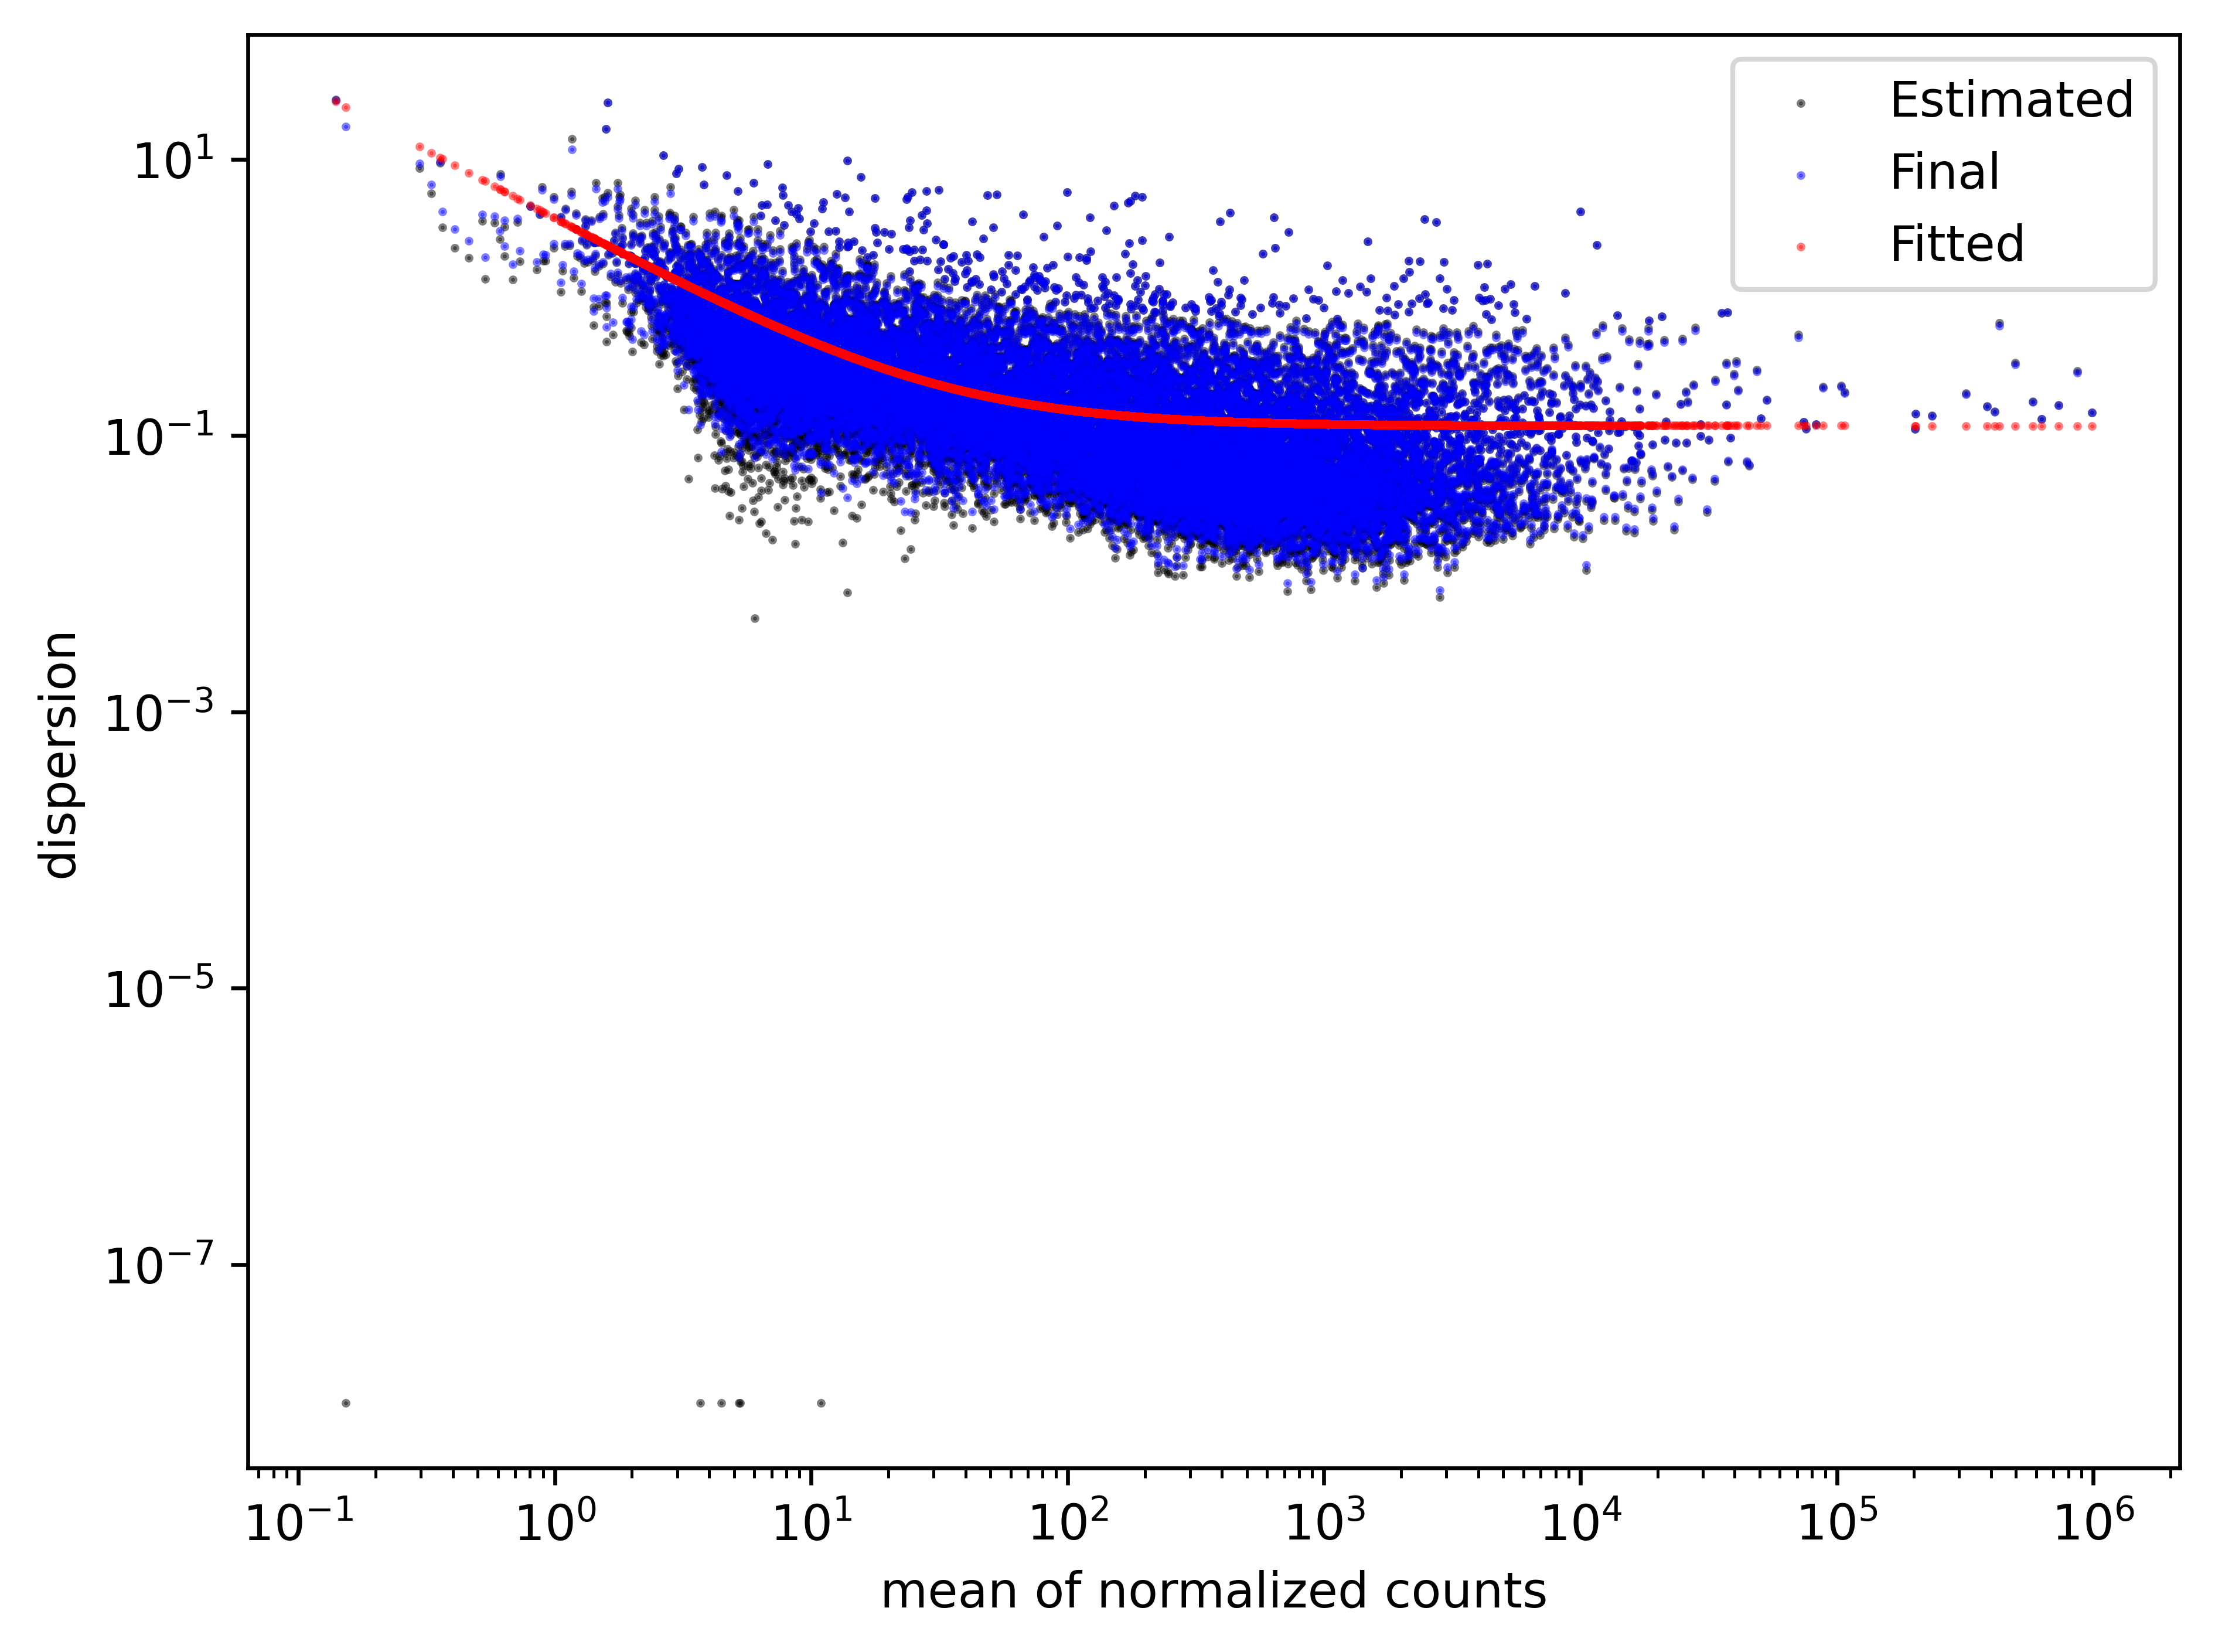

In [ ]:
dds.plot_dispersions()

In [ ]:
# Estrai risultati: POST vs PRE
stat_res = DeseqStats(dds, contrast=['condition', 'POST', 'PRE'])
stat_res.summary()

results = stat_res.results_df.copy()
results.index.name = 'gene'

print(f"\nRisultati: {len(results)} geni")
results.head(10)

Running Wald tests...


Log2 fold change & Wald test p-value: condition POST vs PRE
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene                                                                         
7SK          9.528458        0.174435  0.213741  0.816103  0.414441  0.718604
A1BG-AS1     4.603995       -0.307779  0.223592 -1.376520  0.168661  0.460446
A1CF      1073.814460        0.062543  0.190775  0.327834  0.743037  0.907713
A2M       7690.924161        0.191941  0.131529  1.459310  0.144480  0.423482
A2M-AS1     22.230694       -0.197499  0.145444 -1.357904  0.174494  0.468382
...               ...             ...       ...       ...       ...       ...
ago.02      42.879670        0.446742  0.107111  4.170835  0.000030  0.000687
ago.03     369.471099       -0.004708  0.063414 -0.074242  0.940818  0.980871
ago.04     120.081704        0.007593  0.068065  0.111557  0.911174  0.971990
gen.01      78.068227        0.059880  0.117112  0.511303  0.609139  0.839983
snoU

... done in 4.82 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
7SK,9.528458,0.174435,0.213741,0.816103,0.414441,0.718604
A1BG-AS1,4.603995,-0.307779,0.223592,-1.376520,0.168661,0.460446
A1CF,1073.814460,0.062543,0.190775,0.327834,0.743037,0.907713
A2M,7690.924161,0.191941,0.131529,1.459310,0.144480,0.423482
A2M-AS1,22.230694,-0.197499,0.145444,-1.357904,0.174494,0.468382
A2MP1,4.638507,0.546019,0.265338,2.057824,0.039607,0.197375
A4GALT,83.604297,-0.088060,0.169050,-0.520915,0.602426,0.836459
AAAS,904.002017,0.079340,0.060157,1.318865,0.187214,0.485288
AACS,302.561324,-0.021670,0.086741,-0.249824,0.802724,0.932935


In [ ]:
# Statistiche DE
# Soglie articolo: FDR < 0.05 (EdgeR)
sig_article = results[(results['padj'] < 0.05) & (results['log2FoldChange'].abs() >= 1)]
n_up = (sig_article['log2FoldChange'] > 0).sum()
n_down = (sig_article['log2FoldChange'] < 0).sum()

print(f"=== Soglie stringenti (|log2FC|≥1, FDR<0.05) ===")
print(f"  {len(sig_article)} DEG ({n_up} up, {n_down} down)")

# Soglie pipeline
sig_pipe = results[(results['padj'] < 0.05) & (results['log2FoldChange'].abs() > 0.379)]
n_up_p = (sig_pipe['log2FoldChange'] > 0).sum()
n_down_p = (sig_pipe['log2FoldChange'] < 0).sum()

print(f"\n=== Soglie pipeline (|log2FC|>0.379, FDR<0.05) ===")
print(f"  {len(sig_pipe)} DEG ({n_up_p} up, {n_down_p} down)")

=== Soglie stringenti (|log2FC|≥1, FDR<0.05) ===
  358 DEG (309 up, 49 down)

=== Soglie pipeline (|log2FC|>0.379, FDR<0.05) ===
  1177 DEG (830 up, 347 down)


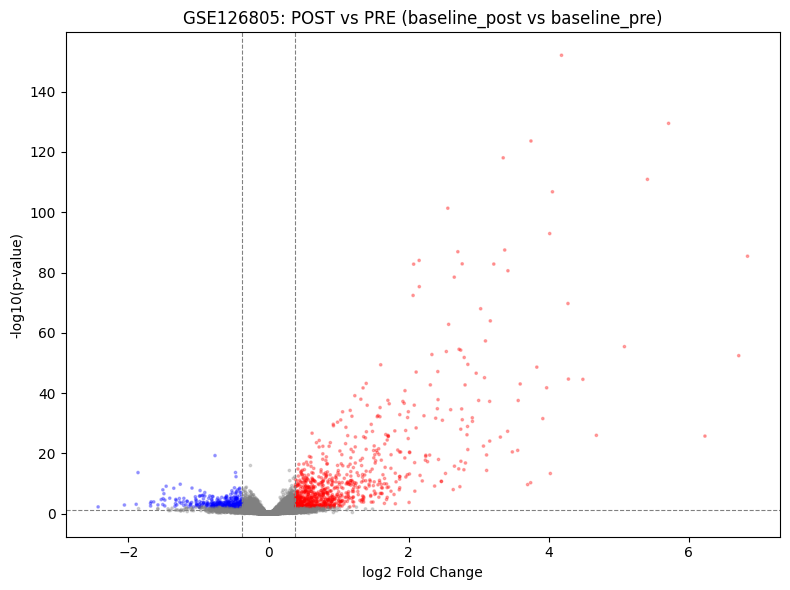

In [ ]:
# Volcano plot
fig, ax = plt.subplots(figsize=(8, 6))

r = results.dropna(subset=['pvalue', 'log2FoldChange'])
r['-log10p'] = -np.log10(r['pvalue'].clip(lower=1e-300))

colors = np.where(
    (r['padj'] < 0.05) & (r['log2FoldChange'] > 0.379), 'red',
    np.where(
        (r['padj'] < 0.05) & (r['log2FoldChange'] < -0.379), 'blue', 'grey'
    )
)

ax.scatter(r['log2FoldChange'], r['-log10p'], c=colors, alpha=0.3, s=3)
ax.axhline(-np.log10(0.05), ls='--', c='grey', lw=0.8)
ax.axvline(0.379, ls='--', c='grey', lw=0.8)
ax.axvline(-0.379, ls='--', c='grey', lw=0.8)
ax.set_xlabel('log2 Fold Change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('GSE126805: POST vs PRE (baseline_post vs baseline_pre)')
plt.tight_layout()
plt.show()

## 6. Formato output standard

In [ ]:
de_output = results[['log2FoldChange', 'pvalue', 'padj']].copy()
de_output['comparison'] = 'POST_vs_PRE'
de_output['dataset'] = 'GSE126805'
de_output.index.name = 'gene'
de_output = de_output.dropna(subset=['pvalue'])

print(f"Geni nel CSV finale: {len(de_output)}")
de_output.head(10)

Geni nel CSV finale: 18832


,log2FoldChange,pvalue,padj,comparison,dataset
gene,,,,,
7SK,0.174435,0.414441,0.718604,POST_vs_PRE,GSE126805
A1BG-AS1,-0.307779,0.168661,0.460446,POST_vs_PRE,GSE126805
A1CF,0.062543,0.743037,0.907713,POST_vs_PRE,GSE126805
A2M,0.191941,0.144480,0.423482,POST_vs_PRE,GSE126805
A2M-AS1,-0.197499,0.174494,0.468382,POST_vs_PRE,GSE126805
A2MP1,0.546019,0.039607,0.197375,POST_vs_PRE,GSE126805
A4GALT,-0.088060,0.602426,0.836459,POST_vs_PRE,GSE126805
AAAS,0.079340,0.187214,0.485288,POST_vs_PRE,GSE126805
AACS,-0.021670,0.802724,0.932935,POST_vs_PRE,GSE126805


## 7. Verifica geni chiave dall'articolo

L'articolo di Cippà identifica immediate-early response genes (FOS, JUN, EGR1, ATF3, FOSB)  
come upregulated in POST vs PRE. Anche SOX9, KLF5, SOCS3, DUSP1 sono upregulated.

In [ ]:
# Geni chiave dall'articolo (POST vs PRE)
key_genes = {
    # Immediate-early response (upregulated in POST) — Figure 2B
    'FOS': 'up', 'FOSB': 'up', 'JUN': 'up', 'EGR1': 'up', 'ATF3': 'up',
    'DUSP1': 'up', 'KLF6': 'up',
    # Second wave (upregulated in POST)
    'SOX9': 'up', 'KLF5': 'up', 'SOCS3': 'up', 'SOX4': 'up',
    # Injury markers (upregulated post-IRI in late phase, variable in acute POST)
    'HAVCR1': 'variable', 'VCAN': 'variable',
    # Fibrosis (late, variable in acute POST)
    'COL1A1': 'variable', 'COL1A2': 'variable',
}

print(f"{'Gene':12s} {'log2FC':>8s} {'pvalue':>10s} {'padj':>10s} {'Atteso':>8s} {'Match':>6s}")
print("-" * 62)
found = 0
match = 0
for gene, expected in key_genes.items():
    if gene in de_output.index:
        row = de_output.loc[gene]
        # Handle potential duplicates
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        fc = row['log2FoldChange']
        direction = 'up' if fc > 0 else 'down'
        ok = '✅' if expected == 'variable' or direction == expected else '⚠️'
        if ok == '✅': match += 1
        found += 1
        pv = row['pvalue']
        pa = row['padj']
        print(f"{gene:12s} {fc:8.3f} {pv:10.2e} {pa:10.2e} {expected:>8s} {ok:>6s}")
    else:
        print(f"{gene:12s} {'NOT FOUND':>8s}")

print(f"\nGeni trovati: {found}/{len(key_genes)}")
print(f"Direzione coerente: {match}/{found}")

Gene           log2FC     pvalue       padj   Atteso  Match
--------------------------------------------------------------
FOS             5.408  1.22e-111  4.58e-108       up      ✅
FOSB            6.837   3.77e-86   6.45e-83       up      ✅
JUN             4.052  1.63e-107  5.12e-104       up      ✅
EGR1            4.274   1.82e-70   1.72e-67       up      ✅
ATF3            5.710  3.27e-130  3.08e-126       up      ✅
DUSP1           3.371   3.26e-88   6.82e-85       up      ✅
KLF6            2.764   1.27e-83   1.84e-80       up      ✅
SOX9            1.170   5.56e-11   3.34e-09       up      ✅
KLF5            0.762   3.80e-06   1.12e-04       up      ✅
SOCS3           2.910   2.20e-31   5.17e-29       up      ✅
SOX4            0.680   1.05e-05   2.72e-04       up      ✅
HAVCR1          0.169   5.52e-01   8.08e-01 variable      ✅
VCAN            0.033   8.78e-01   9.60e-01 variable      ✅
COL1A1          0.321   1.81e-01   4.77e-01 variable      ✅
COL1A2          0.309   9.84e-02   3.

In [ ]:
# Top 20 DEG per significatività
top20 = de_output.dropna(subset=['padj']).sort_values('padj').head(20)
print("=== Top 20 geni più significativi (POST vs PRE) ===")
print(top20[['log2FoldChange', 'pvalue', 'padj']].to_string())

=== Top 20 geni più significativi (POST vs PRE) ===
            log2FoldChange         pvalue           padj
gene                                                    
KLF4              4.181369  8.515421e-153  1.603624e-148
ATF3              5.709990  3.266780e-130  3.076000e-126
ZFP36             3.745432  2.300590e-124  1.444157e-120
IER2              3.349182  8.674220e-119  4.083823e-115
FOS               5.408274  1.216721e-111  4.582659e-108
JUN               4.052350  1.630128e-107  5.116430e-104
DDIT3             2.558301  4.482806e-102   1.206003e-98
AC020916.1        4.013068   1.155183e-93   2.719302e-90
DUSP1             3.370660   3.260985e-88   6.823429e-85
ANKRD37           2.701720   1.211853e-87   2.282162e-84
FOSB              6.837047   3.765903e-86   6.447225e-83
CCNL1             2.149125   9.245962e-85   1.451000e-81
KLF6              2.763771   1.273112e-83   1.844250e-80
BTG2              3.214698   1.494093e-83   2.009769e-80
RHOB              2.070633   1.60498

## 8. Salvataggio

In [ ]:
# === 8. Salvataggio ===

# 8a. DE per meta-analisi
de_output.to_csv(OUTPUT_DIR / "de_GSE126805_IRI_vs_Control.csv")
print(f"✅ DE: {len(de_output)} geni")

# 8b. Matrice counts (gene × sample, tutti i 163 campioni)
counts_filt.to_csv(OUTPUT_DIR / "expr_GSE126805.csv.gz", compression='gzip')
print(f"✅ Expr: {counts_filt.shape[0]} geni × {counts_filt.shape[1]} campioni")

# 8c. Sample labels (formato standard: sample, condition, patient, dataset)
sample_labels = pd.DataFrame({
    "sample": meta['title'],
    "condition": meta['timepoint_std'].map({
        'PRE': 'Control', 'POST': 'IRI', '3M': '3M', '12M': '12M'
    }),
    "patient": meta['patient'].astype(str),
    "dataset": "GSE126805"
})
sample_labels.to_csv(OUTPUT_DIR / "sample_labels_GSE126805.csv", index=False)
print(f"✅ Labels: {len(sample_labels)} campioni")

✅ DE: 18832 geni
✅ Expr: 18832 geni × 163 campioni
✅ Labels: 163 campioni


In [ ]:
# Riepilogo finale
print("=" * 60)
print("RIEPILOGO GSE126805 — Fase 1 completata")
print("=" * 60)
print(f"Dataset: GSE126805 (Cippà et al., JCI Insight 2018)")
print(f"Tipo: RNA-seq (STAR/featureCounts), counts gene-level forniti dagli autori")
print(f"Design: 42 pazienti, 163 campioni, 4 timepoints")
print(f"Confronto DE: POST vs PRE ({n_post} vs {n_pre} campioni, {len(pts_both)} paired)")
print(f"Design formula: ~ condition (non paired, n grande)")
print(f"Geni testati: {len(de_output)}")

sig = de_output[(de_output['padj'] < 0.05) & (de_output['log2FoldChange'].abs() > 0.379)]
print(f"DEG (|log2FC|>0.379, FDR<0.05): {len(sig)} ({(sig['log2FoldChange']>0).sum()} up, {(sig['log2FoldChange']<0).sum()} down)")
print(f"")
print(f"File salvati:")
print(f"  {OUTPUT_DIR / 'de_GSE126805_IRI_vs_Control.csv'}")
print(f"  {OUTPUT_DIR / 'sample_labels_GSE126805.csv'}")
print(f"  {OUTPUT_DIR / 'expr_GSE126805.csv.gz'}")
print(f"")
print(f"Note:")
print(f"  - Design ~ condition (senza paired) per evitare troppi parametri con 42 pazienti")
print(f"  - L'articolo originale usa EdgeR, noi pyDESeq2 — differenze minime attese")
print(f"  - I campioni a 3M e 12M non sono usati per DE ma sono nei labels per analisi future")

RIEPILOGO GSE126805 — Fase 1 completata
Dataset: GSE126805 (Cippà et al., JCI Insight 2018)
Tipo: RNA-seq (STAR/featureCounts), counts gene-level forniti dagli autori
Design: 42 pazienti, 163 campioni, 4 timepoints
Confronto DE: POST vs PRE (42 vs 41 campioni, 41 paired)
Design formula: ~ condition (non paired, n grande)
Geni testati: 18832
DEG (|log2FC|>0.379, FDR<0.05): 1177 (830 up, 347 down)

File salvati:
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\GSE126805\de_GSE126805_IRI_vs_Control.csv
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\GSE126805\sample_labels_GSE126805.csv
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\GSE126805\expr_GSE126805.csv.gz

Note:
  - Design ~ condition (senza paired) per evitare troppi parametri con 42 pazienti
  - L'articolo originale usa EdgeR, noi pyDESeq2 — differenze minime attese
  - I campioni a 3M e 12M non sono usati per DE ma sono nei labels per analisi future
